# 22 — Synthetic Historical Control on the monthly latent panel

Design: memory `project-shc-corrected-design` / plan `quirky-growing-wombat`. Estimator in
`panel_shc.py` (paper + 4 Sep 2026 meeting only), driver `panel_shc_run.py`, data
`latents_monthly_long{,_histfill}.npz` from `panel_monthly_encode.py`.

* pre = P01–P10 (Nov 2023–Aug 2024), **P11 = Sep 2024 is the treatment period**, post = P11–P12 (n = 2) or P11–P13 (n = 3)
* outcome = the 980-d TerraMind tokenizer latent (5 × 14 × 14), one weight vector per site × sensor over all 980 coordinates
* stage 1 = local-linear kernel smoothing of every coordinate along time over the pre-period, bandwidth by leave-one-out CV per site
* donors = the site's own shifted blocks, stepwise selection (ζ = 0.001 % of the pre-period variance); "Single" and "All-in" alongside
* validation = temporal placebo (same m, n, window ending at P(10 − n)) and negative-control sites (the 10 matched counterfactuals)

Every number below is read from the CSVs; nothing is typed.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import panel_lib as pl
pl.set_plot_style(); pd.set_option("display.width", 250); pd.set_option("display.max_columns", 60)
F = pd.read_csv("panel_shc_fits.csv"); E = pd.read_csv("panel_shc_effects.csv")
H = pd.read_csv("panel_shc_bandwidth.csv"); P = pd.read_csv("panel_shc_path.csv"); S = pd.read_csv("panel_shc_summary.csv")
T = F[F.group == "treatment"]
print(len(F), "fits;", T.site.nunique(), "treated sites;", F[F.group=="counterfactual"].site.nunique(), "control sites")
print("fills", sorted(F.fill.unique()), "| n", sorted(F.n.unique()), "| m", sorted(F.m.unique()))

7722 fits; 26 treated sites; 260 control sites
fills ['chipmean', 'histfill'] | n [np.int64(2), np.int64(3)] | m [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


## 1. Stage 1 — bandwidths chosen by leave-one-out CV (treated sites, effect window P01–P10)

                    sites  h_median     h_min     h_max  interior  floor  ceiling
fill     sensor                                                                  
chipmean sentinel1     12  0.712643  0.501187  1.995262        12      0        0
         sentinel2     15  0.501187  0.158489  1.258925        15      0        0
histfill sentinel1     12  0.712643  0.501187  1.995262        12      0        0
         sentinel2     15  0.501187  0.158489  1.000000        15      0        0


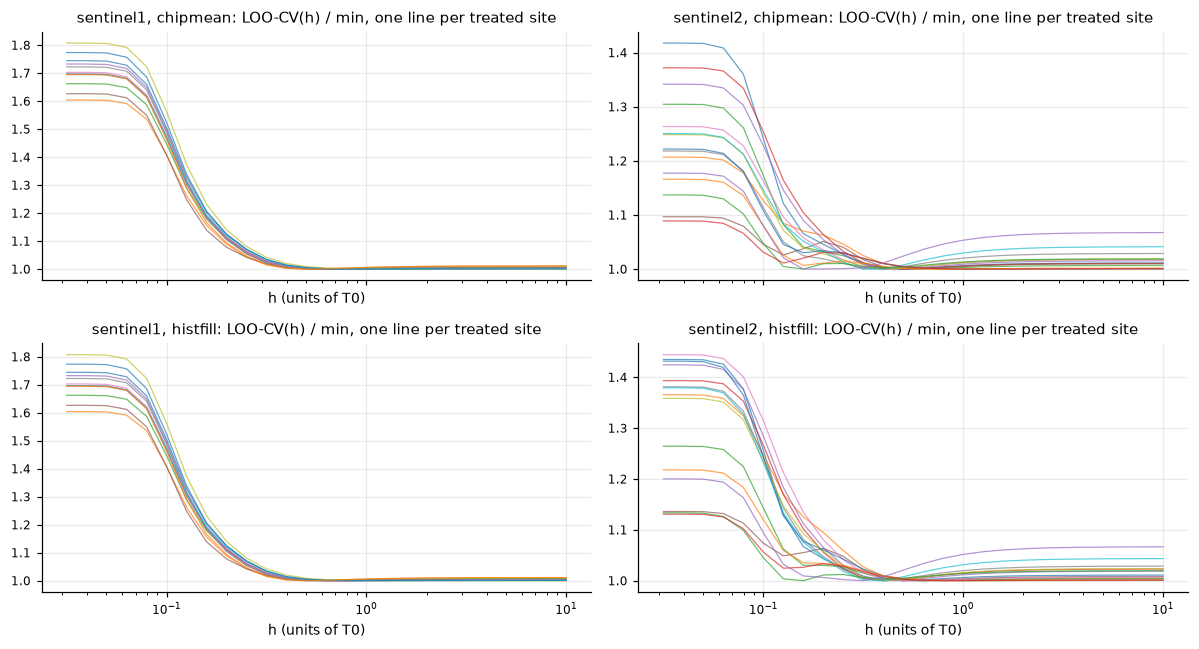

In [2]:
hh = T[T.m == T.m.min()][["fill","sensor","site","h","h_flag"]].drop_duplicates(["fill","sensor","site"])
print(hh.groupby(["fill","sensor"]).agg(sites=("site","nunique"), h_median=("h","median"), h_min=("h","min"), h_max=("h","max"),
                                       interior=("h_flag", lambda v: int((v=="interior").sum())),
                                       floor=("h_flag", lambda v: int((v=="floor").sum())),
                                       ceiling=("h_flag", lambda v: int((v=="ceiling").sum()))).to_string())
fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharex=True)
for ax, ((fill, sensor), g) in zip(axes.ravel(), H.groupby(["fill","sensor"])):
    for site, gs in g.groupby("site"):
        gs = gs.sort_values("h"); ax.plot(gs.h, gs.cv / gs.cv.min(), lw=0.8, alpha=0.7)
    ax.set_xscale("log"); ax.set_title(f"{sensor}, {fill}: LOO-CV(h) / min, one line per treated site"); ax.set_xlabel("h (units of T0)")
plt.tight_layout(); plt.savefig("panel_shc_bandwidth.png", dpi=110); plt.show()

## 2. Temporal placebo (validation): RMSE over the 980 coordinates at the held-out pre-Helene periods, mean over treated sites

Reference row = the site's own P01..P(10−n) mean. Rule (b) for m reads this table.

In [3]:
cols = ["fill","sensor","n","m","N","placebo_sites","placebo_rmse","placebo_rmse_raw","placebo_rmse_ownmean","placebo_beats_ownmean","n_eff_mean","most_recent_only","n_selected_mean"]
for sensor in ("sentinel1","sentinel2"):
    print(f"\n=== {sensor} ===")
    print(S[S.sensor == sensor][[c for c in cols if c in S]].sort_values(["fill","n","m"]).to_string(index=False, float_format=lambda v: f"{v:.4f}"))


=== sentinel1 ===
    fill    sensor  n  m  N  placebo_sites  placebo_rmse  placebo_rmse_raw  placebo_rmse_ownmean  placebo_beats_ownmean  n_eff_mean  most_recent_only  n_selected_mean
chipmean sentinel1  2  2  7        12.0000        0.2303            0.2666                0.2360                11.0000      1.0000                12           1.0000
chipmean sentinel1  2  3  6        12.0000        0.2303            0.2666                0.2360                11.0000      1.0000                12           1.0000
chipmean sentinel1  2  4  5        12.0000        0.2303            0.2666                0.2360                11.0000      1.0000                12           1.0000
chipmean sentinel1  2  5  4        12.0000        0.2303            0.2666                0.2360                11.0000      1.0000                12           1.0000
chipmean sentinel1  2  6  3        12.0000        0.2303            0.2666                0.2360                11.0000      1.0000               

## 3. Pre-period matching, donor selection and the two m rules

In [4]:
cols = ["fill","sensor","n","m","N","mse_pre_mean","passes_nu","most_recent_only","n_selected_mean","n_eff_mean"]
print(S[[c for c in cols if c in S]].sort_values(["sensor","fill","n","m"]).to_string(index=False, float_format=lambda v: f"{v:.5f}"))
# rule (a): largest m with MSE_pre <= nu, per site; rule (b): m with the smallest placebo error, per site
rows = []
for (fill, sensor, n, site), g in T.groupby(["fill","sensor","n","site"]):
    ok = g[(g.ok == True) & (g.passes_nu == True)]
    gp = g[g.placebo_ok == True]
    rows.append({"fill": fill, "sensor": sensor, "n": n, "site": site,
                 "m_rule_a": int(ok.m.max()) if len(ok) else np.nan,
                 "m_rule_b": int(gp.loc[gp.placebo_rmse.idxmin(), "m"]) if len(gp) else np.nan})
R = pd.DataFrame(rows)
print(R.groupby(["fill","sensor","n"]).agg(sites=("site","nunique"), m_a_median=("m_rule_a","median"), m_a_min=("m_rule_a","min"), m_a_max=("m_rule_a","max"),
                                          m_b_median=("m_rule_b","median"), m_b_min=("m_rule_b","min"), m_b_max=("m_rule_b","max")).to_string())

    fill    sensor  n  m  N  mse_pre_mean  passes_nu  most_recent_only  n_selected_mean  n_eff_mean
chipmean sentinel1  2  2  7       0.00431          0                12          1.00000     1.00000
chipmean sentinel1  2  3  6       0.00418          0                12          1.00000     1.00000
chipmean sentinel1  2  4  5       0.00406          0                12          1.00000     1.00000
chipmean sentinel1  2  5  4       0.00396          0                12          1.00000     1.00000
chipmean sentinel1  2  6  3       0.00387          0                12          1.00000     1.00000
chipmean sentinel1  2  7  2       0.00380          0                12          1.00000     1.00000
chipmean sentinel1  2  8  1       0.00375          0                12          1.00000     1.00000
chipmean sentinel1  3  2  6       0.00938          0                12          1.00000     1.00000
chipmean sentinel1  3  3  5       0.00911          0                12          1.00000     1.00000


                      sites  m_a_median  m_a_min  m_a_max  m_b_median  m_b_min  m_b_max
fill     sensor    n                                                                   
chipmean sentinel1 2     12         NaN      NaN      NaN         2.0        2        2
                   3     12         NaN      NaN      NaN         2.0        2        2
         sentinel2 2     15         NaN      NaN      NaN         2.0        2        2
                   3     15         NaN      NaN      NaN         2.0        2        2
histfill sentinel1 2     12         NaN      NaN      NaN         2.0        2        2
                   3     12         NaN      NaN      NaN         2.0        2        2
         sentinel2 2     15         NaN      NaN      NaN         2.0        2        2
                   3     15         NaN      NaN      NaN         2.0        2        2


## 4. Effect run: treated sites, T₀ = P10, post P11… — per site donor diagnostics and effect size

‖Δ̂‖/√980 per post period; negative-control rank = position of the treated site's mean |Δ̂| among its 10 matched counterfactual sites (1 = largest). Block numbering: 1 = most recent (shift n), N = oldest.

In [5]:
def site_table(fill, sensor, n, m):
    t = T[(T.fill==fill)&(T.sensor==sensor)&(T.n==n)&(T.m==m)&(T.ok==True)]
    Cc = F[(F.group=="counterfactual")&(F.fill==fill)&(F.sensor==sensor)&(F.n==n)&(F.m==m)&(F.ok==True)]
    out = []
    for _, r in t.iterrows():
        c = Cc[Cc.matched_treatment == r.site]
        rank = 1 + int((c.delta_rms_mean >= r.delta_rms_mean).sum()) if len(c) else np.nan
        out.append({"site": r.site, "h": r.h, "flag": r.h_flag, "N": r.N, "selected": r.selected, "w": r.w, "n_eff": r.n_eff,
                    "mse_pre": r.mse_pre, "passes_nu": r.passes_nu, "delta_rms_mean": r.delta_rms_mean,
                    **{f"delta_k{k}": r.get(f"delta_rms_k{k}", np.nan) for k in range(1, n+1)},
                    "nc_rank": rank, "nc_n": len(c), "nc_p": rank/(1+len(c)) if len(c) else np.nan,
                    "placebo_rmse": r.get("placebo_rmse", np.nan), "placebo_ownmean": r.get("placebo_rmse_ownmean", np.nan)})
    return pd.DataFrame(out)
for sensor in ("sentinel1","sentinel2"):
    for fill in ("chipmean","histfill"):
        for n in (2, 3):
            m = 4
            print(f"\n=== {sensor}, {fill}, n = {n}, m = {m} ===")
            print(site_table(fill, sensor, n, m).to_string(index=False, float_format=lambda v: f"{v:.4f}"))


=== sentinel1, chipmean, n = 2, m = 4 ===
          site      h     flag  N selected      w  n_eff  mse_pre  passes_nu  delta_rms_mean  delta_k1  delta_k2  nc_rank  nc_n   nc_p  placebo_rmse  placebo_ownmean
treatment_0015 0.7943 interior  5        1 1.0000 1.0000   0.0041      False          0.2677    0.2464    0.2891        3    10 0.2727        0.2534           0.2557
treatment_0016 0.5012 interior  5        1 1.0000 1.0000   0.0051      False          0.2448    0.2114    0.2783        6    10 0.5455        0.2513           0.2495
treatment_0017 0.6310 interior  5        1 1.0000 1.0000   0.0041      False          0.2264    0.1998    0.2530       11    10 1.0000        0.2245           0.2332
treatment_0018 0.7943 interior  5        1 1.0000 1.0000   0.0040      False          0.2244    0.1936    0.2553        9    10 0.8182        0.2136           0.2285
treatment_0019 0.7943 interior  5        1 1.0000 1.0000   0.0039      False          0.2359    0.2056    0.2662       10    10

          site      h     flag  N selected      w  n_eff  mse_pre  passes_nu  delta_rms_mean  delta_k1  delta_k2  nc_rank  nc_n   nc_p  placebo_rmse  placebo_ownmean
treatment_0015 0.7943 interior  5        1 1.0000 1.0000   0.0041      False          0.2677    0.2464    0.2891        3    10 0.2727        0.2534           0.2557
treatment_0016 0.5012 interior  5        1 1.0000 1.0000   0.0051      False          0.2448    0.2114    0.2783        6    10 0.5455        0.2513           0.2495
treatment_0017 0.6310 interior  5        1 1.0000 1.0000   0.0041      False          0.2264    0.1998    0.2530       11    10 1.0000        0.2245           0.2332
treatment_0018 0.7943 interior  5        1 1.0000 1.0000   0.0040      False          0.2244    0.1936    0.2553        9    10 0.8182        0.2136           0.2285
treatment_0019 0.7943 interior  5        1 1.0000 1.0000   0.0039      False          0.2359    0.2056    0.2662       10    10 0.9091        0.2312           0.2365
trea

          site      h     flag  N selected      w  n_eff  mse_pre  passes_nu  delta_rms_mean  delta_k1  delta_k2  nc_rank  nc_n   nc_p  placebo_rmse  placebo_ownmean
treatment_0001 0.5012 interior  5        1 1.0000 1.0000   0.0060      False          0.2402    0.2268    0.2536        2    10 0.1818        0.2264           0.2414
treatment_0002 0.6310 interior  5        1 1.0000 1.0000   0.0049      False          0.2307    0.2212    0.2402        2    10 0.1818        0.2227           0.2329
treatment_0003 0.6310 interior  5        1 1.0000 1.0000   0.0072      False          0.2193    0.1755    0.2632        8    10 0.7273        0.2092           0.2474
treatment_0004 0.3981 interior  5        1 1.0000 1.0000   0.0057      False          0.2076    0.2185    0.1968       10    10 0.9091        0.2454           0.2341
treatment_0005 0.3981 interior  5        1 1.0000 1.0000   0.0062      False          0.2176    0.2091    0.2261        9    10 0.8182        0.2245           0.2345
trea

## 5. Effect by post period and channel (treated sites), with the negative-control distribution

In [6]:
Et = E.copy()
for sensor in ("sentinel1","sentinel2"):
    g = Et[(Et.sensor==sensor)&(Et.m==4)]
    print(f"\n=== {sensor}, m = 4: mean over sites of ||Delta||/sqrt(980) by post period, treated vs controls ===")
    print(g.groupby(["fill","n","post_period","group"]).agg(sites=("site","nunique"), delta_rms=("delta_rms","mean"),
          delta_raw=("delta_raw_rms","mean"), valid=("valid_frac","mean")).round(4).to_string())
ch = [f"delta_ch{c}" for c in range(1,6)]
print("\nper-channel mean Delta (treated, m = 4, n = 2, historical fill):")
print(Et[(Et.m==4)&(Et.n==2)&(Et.fill=="histfill")&(Et["group"]=="treatment")].groupby(["sensor","post_period"])[ch].mean().round(4).to_string())


=== sentinel1, m = 4: mean over sites of ||Delta||/sqrt(980) by post period, treated vs controls ===
                                       sites  delta_rms  delta_raw   valid
fill     n post_period group                                              
chipmean 2 P11         counterfactual    120     0.2134     0.2688  0.9988
                       treatment          12     0.2086     0.2595  0.9983
           P12         counterfactual    120     0.2638     0.3025  0.9988
                       treatment          12     0.2648     0.3007  0.9983
         3 P11         counterfactual    120     0.2080     0.2746  0.9988
                       treatment          12     0.2037     0.2686  0.9983
           P12         counterfactual    120     0.2528     0.3034  0.9988
                       treatment          12     0.2528     0.3008  0.9983
           P13         counterfactual    120     0.2582     0.3007  0.9988
                       treatment          12     0.2644     0.3027  0.998

## 6. Stepwise donor selection paths (treated sites, m = 4, n = 2)

In [7]:
pp = P[(P.kind=="path")&(P.m==4)&(P.n==2)]
print(pp.groupby(["fill","sensor","step","accepted"]).size().unstack(fill_value=0).to_string())
print("\nwhich block is picked first (1 = most recent, shift n; N = oldest):")
print(pp[pp.step==1].groupby(["fill","sensor","added"]).size().unstack(fill_value=0).to_string())

accepted                 False  True 
fill     sensor    step              
chipmean sentinel1 1         0     12
                   2        12      0
         sentinel2 1         0     15
                   2        15      0
histfill sentinel1 1         0     12
                   2        12      0
         sentinel2 1         0     15
                   2        15      0

which block is picked first (1 = most recent, shift n; N = oldest):
added               1.0
fill     sensor        
chipmean sentinel1   12
         sentinel2   15
histfill sentinel1   12
         sentinel2   15
